In [14]:
!pip install pandas numpy scikit-learn matplotlib seaborn streamlit scipy

In [15]:
import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. LOAD DATA FROM GITHUB OR YOUR COLAB UPLOAD
# ============================================================================
# Option A: Upload files to Colab
from google.colab import files
print("Upload daily_data.csv:")
uploaded = files.upload()

# Read the data
daily = pd.read_csv('daily_data.csv')

# Parse timestamps
daily['date_time'] = pd.to_datetime(daily['date_time'])
daily['date'] = pd.to_datetime(daily['date'])

# ============================================================================
# 2. EXTRACT TEMPORAL FEATURES
# ============================================================================
print("Creating temporal features...")
daily['hour'] = daily['date_time'].dt.hour
daily['day_of_week'] = daily['date_time'].dt.dayofweek
daily['month'] = daily['date_time'].dt.month
daily['day_of_month'] = daily['date_time'].dt.day
daily['is_weekend'] = daily['day_of_week'].isin([5, 6]).astype(int)
daily['is_morning'] = daily['hour'].isin([5, 6, 7, 8, 9]).astype(int)
daily['is_evening'] = daily['hour'].isin([16, 17, 18, 19, 20]).astype(int)
daily['is_night'] = daily['hour'].isin([0, 1, 2, 3, 4]).astype(int)

# ============================================================================
# 3. OCCUPANCY FEATURES
# ============================================================================
print("Creating occupancy features...")
occ_cols = [col for col in daily.columns if col.startswith('occ_')]
daily['occupancy_count'] = (daily[occ_cols] == 'Occupied').sum(axis=1)
daily['occupancy_ratio'] = daily['occupancy_count'] / len(occ_cols)
daily['all_occupied'] = (daily['occupancy_count'] == 5).astype(int)
daily['none_occupied'] = (daily['occupancy_count'] == 0).astype(int)

# ============================================================================
# 4. WATER USAGE STATISTICAL FEATURES
# ============================================================================
print("Creating statistical features...")

daily_sorted = daily.sort_values(['building', 'date_time']).reset_index(drop=True)

for building in daily['building'].unique():
    mask = daily_sorted['building'] == building
    building_data = daily_sorted[mask].copy()

    daily_sorted.loc[mask, 'rolling_mean_7d'] = building_data['water_use_l'].rolling(
        window=7, min_periods=1, center=False
    ).mean().values

    daily_sorted.loc[mask, 'rolling_std_7d'] = building_data['water_use_l'].rolling(
        window=7, min_periods=1, center=False
    ).std().values

    daily_sorted.loc[mask, 'deviation_from_mean'] = (
        building_data['water_use_l'].values -
        daily_sorted.loc[mask, 'rolling_mean_7d'].values
    )

daily = daily_sorted

# ============================================================================
# 5. CONTEXT-AWARE FEATURES
# ============================================================================
print("Creating context-aware features...")

daily['expected_usage'] = 2 * daily['occupancy_count']
daily['usage_vs_occupancy'] = daily['water_use_l'] - daily['expected_usage']

daily['usage_percentile'] = daily.groupby('building')['water_use_l'].transform(
    lambda x: (x.rank(pct=True) * 100).round(2)
)

daily['usage_by_hour_baseline'] = daily.groupby('hour')['water_use_l'].transform('mean')
daily['usage_vs_hour_baseline'] = daily['water_use_l'] - daily['usage_by_hour_baseline']

# ============================================================================
# 6. DEFINE ANOMALY LABELS
# ============================================================================
print("Defining anomaly labels...")

daily['is_anomaly'] = 0

# Rule 1: Statistical anomalies
rule1 = daily['deviation_from_mean'] > (3 * daily['rolling_std_7d'])
daily.loc[rule1, 'is_anomaly'] = 1

# Rule 2: Context-aware (high usage with low occupancy)
rule2 = (daily['water_use_l'] > daily['water_use_l'].quantile(0.9)) & \
        (daily['occupancy_count'] < 2)
daily.loc[rule2, 'is_anomaly'] = 1

# Rule 3: Zero usage when occupied (sensor issue)
rule3 = (daily['water_use_l'] == 0) & (daily['occupancy_count'] >= 3) & \
        (daily['is_morning'] == 1)
daily.loc[rule3, 'is_anomaly'] = 1

print(f"Total anomalies labeled: {daily['is_anomaly'].sum()} ({(daily['is_anomaly'].sum()/len(daily)*100):.2f}%)")

# ============================================================================
# 7. PREPARE FINAL DATASET (FIXED - INCLUDES water_use_l)
# ============================================================================
print("Preparing final dataset...")

feature_cols = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'is_morning', 'is_evening', 'is_night',
    'occupancy_count', 'occupancy_ratio', 'all_occupied', 'none_occupied',
    'rolling_mean_7d', 'rolling_std_7d', 'deviation_from_mean',
    'expected_usage', 'usage_vs_occupancy', 'usage_percentile', 'usage_vs_hour_baseline'
]

# FIXED: Include water_use_l in the final dataset
modeling_data = daily[['building', 'date_time', 'water_use_l'] + feature_cols + ['is_anomaly']].copy()
modeling_data = modeling_data.fillna(modeling_data.groupby('building').transform('mean'))

print("\n" + "="*70)
print("FEATURE ENGINEERING COMPLETE")
print("="*70)
print(f"Dataset shape: {modeling_data.shape}")
print(f"Features: {len(feature_cols)}")
print(f"\nClass distribution:")
print(modeling_data['is_anomaly'].value_counts())
print(f"\nClass balance: {(modeling_data['is_anomaly'].sum()/len(modeling_data)*100):.2f}% anomalies")

print("\nSample of engineered features:")
print(modeling_data.head(10))

print("\nColumn names:")
print(modeling_data.columns.tolist())

# Save for next step
modeling_data.to_csv('features_engineered.csv', index=False)
print("\n✅ Features saved!")

Upload daily_data.csv:


Saving daily_data.csv to daily_data (1).csv
Creating temporal features...
Creating occupancy features...
Creating statistical features...
Creating context-aware features...
Defining anomaly labels...
Total anomalies labeled: 4673 (5.35%)
Preparing final dataset...

FEATURE ENGINEERING COMPLETE
Dataset shape: (87360, 22)
Features: 18

Class distribution:
is_anomaly
0    82687
1     4673
Name: count, dtype: int64

Class balance: 5.35% anomalies

Sample of engineered features:
     building                 date_time  water_use_l  hour  day_of_week  \
0  BUILD-D-01 2022-01-01 11:00:00+00:00            5    11            5   
1  BUILD-D-01 2022-01-01 12:00:00+00:00           35    12            5   
2  BUILD-D-01 2022-01-01 13:00:00+00:00           29    13            5   
3  BUILD-D-01 2022-01-01 14:00:00+00:00           40    14            5   
4  BUILD-D-01 2022-01-01 15:00:00+00:00           12    15            5   
5  BUILD-D-01 2022-01-01 16:00:00+00:00           10    16            5

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report
)
import pickle

# ============================================================================
# 1. LOAD ENGINEERED FEATURES
# ============================================================================
print("Loading engineered features...")
data = pd.read_csv('features_engineered.csv')

feature_cols = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'is_morning', 'is_evening', 'is_night',
    'occupancy_count', 'occupancy_ratio', 'all_occupied', 'none_occupied',
    'rolling_mean_7d', 'rolling_std_7d', 'deviation_from_mean',
    'expected_usage', 'usage_vs_occupancy', 'usage_percentile', 'usage_vs_hour_baseline'
]

X = data[feature_cols]
y = data['is_anomaly']

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}\n")

# ============================================================================
# 2. SPLIT DATA
# ============================================================================
print("Splitting data (80/20, stratified)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# ============================================================================
# 3. SCALE FEATURES
# ============================================================================
print("\nScaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================================
# 4. TRAIN MULTIPLE MODELS
# ============================================================================
print("\n" + "="*70)
print("TRAINING MODELS")
print("="*70)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced'),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42,
                                           class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5,
                                                     learning_rate=0.1, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    if name in ['Logistic Regression', 'KNN (k=5)']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None

    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'cm': confusion_matrix(y_test, y_pred)
    }

    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if roc_auc:
        print(f"  ROC-AUC:   {roc_auc:.4f}")

# ============================================================================
# 5. COMPARISON & BEST MODEL
# ============================================================================
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Model': results.keys(),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1'] for m in results.keys()],
    'ROC-AUC': [results[m]['roc_auc'] for m in results.keys()],
})

print("\n" + comparison_df.to_string(index=False))

best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
print(f"\n✅ Best Model: {best_model_name} (F1: {comparison_df['F1-Score'].max():.4f})")

# ============================================================================
# 6. DETAILED EVALUATION OF BEST MODEL
# ============================================================================
print(f"\n{'='*70}")
print(f"DETAILED EVALUATION: {best_model_name}")
print(f"{'='*70}")

best_results = results[best_model_name]
cm = best_results['cm']
y_pred_best = best_results['y_pred']

print(f"\nConfusion Matrix:")
print(f"  True Negatives (TN):  {cm[0,0]}")
print(f"  False Positives (FP): {cm[0,1]}")
print(f"  False Negatives (FN): {cm[1,0]}")
print(f"  True Positives (TP):  {cm[1,1]}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Normal', 'Anomaly']))

# ============================================================================
# 7. SAVE BEST MODEL & SCALER
# ============================================================================
print(f"\nSaving best model...")
best_model = results[best_model_name]['model']
pickle.dump(best_model, open('best_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

with open('feature_columns.txt', 'w') as f:
    for col in feature_cols:
        f.write(col + '\n')

print("✅ Model saved!")
print("✅ Scaler saved!")
print("✅ Feature columns saved!")

Loading engineered features...
Features shape: (87360, 18)
Target distribution:
is_anomaly
0    82687
1     4673
Name: count, dtype: int64

Splitting data (80/20, stratified)...
Train set: (69888, 18)
Test set: (17472, 18)

Scaling features...

TRAINING MODELS

Training Logistic Regression...
  Accuracy:  0.9852
  Precision: 0.7840
  Recall:    0.9979
  F1-Score:  0.8781
  ROC-AUC:   0.9966

Training Decision Tree...
  Accuracy:  0.9999
  Precision: 1.0000
  Recall:    0.9989
  F1-Score:  0.9995
  ROC-AUC:   0.9995

Training KNN (k=5)...
  Accuracy:  0.9988
  Precision: 0.9821
  Recall:    0.9957
  F1-Score:  0.9888
  ROC-AUC:   0.9998

Training Random Forest...
  Accuracy:  0.9999
  Precision: 1.0000
  Recall:    0.9989
  F1-Score:  0.9995
  ROC-AUC:   1.0000

Training Gradient Boosting...
  Accuracy:  0.9999
  Precision: 1.0000
  Recall:    0.9989
  F1-Score:  0.9995
  ROC-AUC:   0.9990

MODEL COMPARISON

              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic R

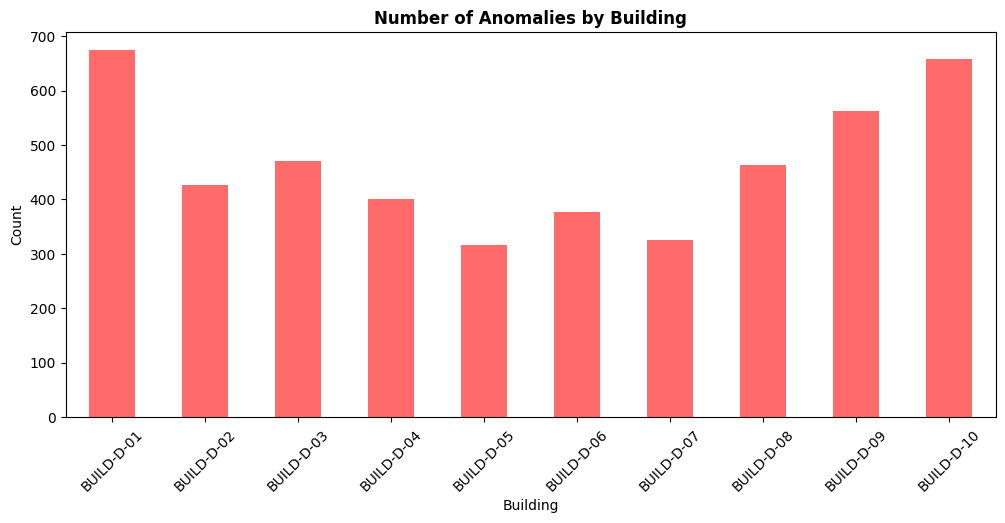

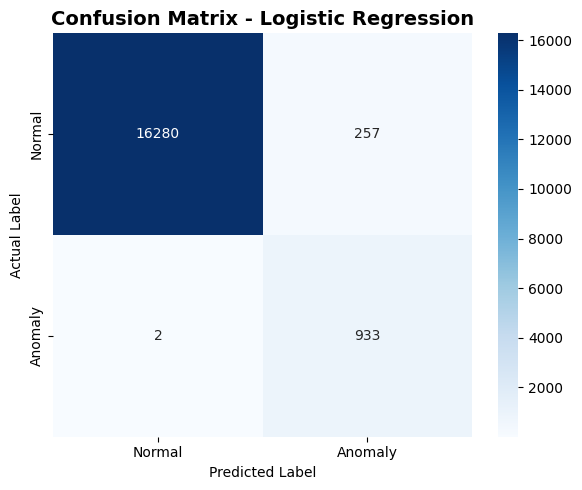

✅ Saved: results/confusion_matrix_logistic_regression.png


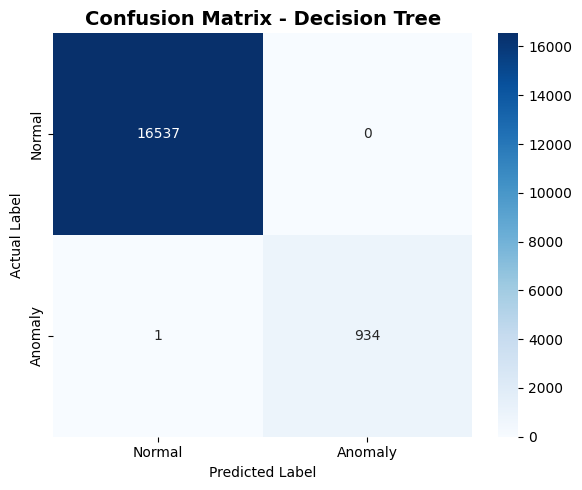

✅ Saved: results/confusion_matrix_decision_tree.png


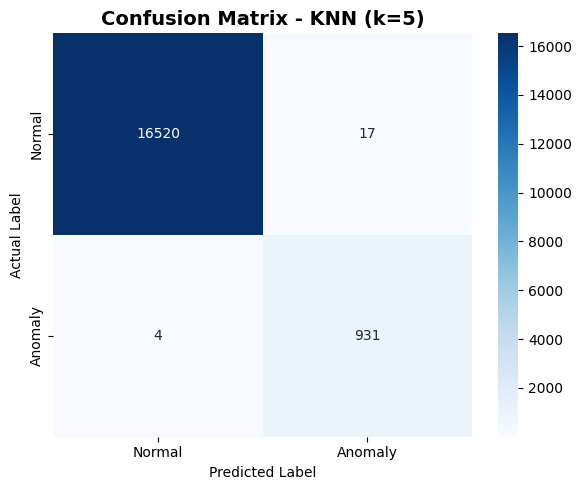

✅ Saved: results/confusion_matrix_knn_k5.png


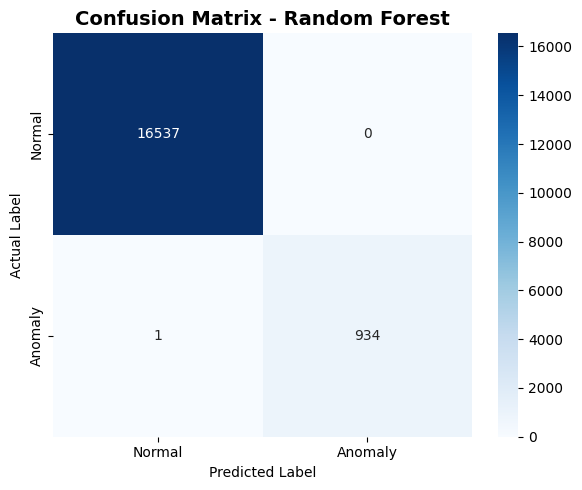

✅ Saved: results/confusion_matrix_random_forest.png


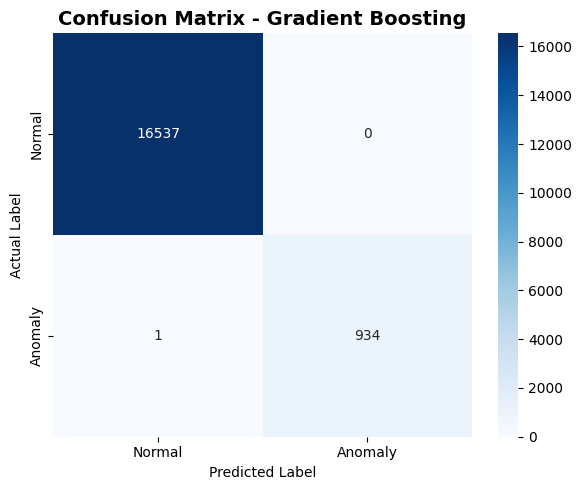

✅ Saved: results/confusion_matrix_gradient_boosting.png


In [17]:
# ============================================================
# CONFUSION MATRICES FOR ALL TRAINED MODELS
# ============================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create results folder
os.makedirs("results", exist_ok=True)

# Generate confusion matrix for every model
for model_name, model_results in results.items():

    cm = model_results["cm"]

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Normal", "Anomaly"],
        yticklabels=["Normal", "Anomaly"]
    )

    plt.title(
        f"Confusion Matrix - {model_name}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.tight_layout()

    # Create safe filename
    filename = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("=", "")
    )

    # Save image
    output_path = f"results/confusion_matrix_{filename}.png"

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"✅ Saved: {output_path}")

In [18]:
# ============================================================================
# LOAD TRAINED MODEL AND MAKE PREDICTIONS
# ============================================================================

# Load model and scaler
best_model = pickle.load(open('best_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

# Load feature columns
with open('feature_columns.txt', 'r') as f:
    feature_cols = [line.strip() for line in f.readlines()]

# ============================================================================
# EXAMPLE: MAKE PREDICTION ON NEW DATA
# ============================================================================

# Create example input
example_input = {
    'hour': 8,
    'day_of_week': 0,
    'month': 6,
    'is_weekend': 0,
    'is_morning': 1,
    'is_evening': 0,
    'is_night': 0,
    'occupancy_count': 5,
    'occupancy_ratio': 1.0,
    'all_occupied': 1,
    'none_occupied': 0,
    'rolling_mean_7d': 10.5,
    'rolling_std_7d': 5.2,
    'deviation_from_mean': 5.0,
    'expected_usage': 10,
    'usage_vs_occupancy': 25,
    'usage_percentile': 55,
    'usage_vs_hour_baseline': 5
}

# Convert to DataFrame
X_new = pd.DataFrame([example_input])

# Scale features
X_new_scaled = scaler.transform(X_new)

# Make prediction
prediction = best_model.predict(X_new_scaled)[0]
probability = best_model.predict_proba(X_new_scaled)[0]

print("="*70)
print("PREDICTION RESULT")
print("="*70)
print(f"\nInput Water Usage: 35 L")
print(f"Time: 8:00 AM, Monday, Morning Peak")
print(f"Occupancy: 5 people (all occupied)")

if prediction == 1:
    print(f"\n🚨 PREDICTION: ANOMALY")
    print(f"Confidence (Anomaly): {probability[1]*100:.2f}%")
    print(f"Confidence (Normal): {probability[0]*100:.2f}%")
else:
    print(f"\n✅ PREDICTION: NORMAL")
    print(f"Confidence (Normal): {probability[0]*100:.2f}%")
    print(f"Confidence (Anomaly): {probability[1]*100:.2f}%")

PREDICTION RESULT

Input Water Usage: 35 L
Time: 8:00 AM, Monday, Morning Peak
Occupancy: 5 people (all occupied)

✅ PREDICTION: NORMAL
Confidence (Normal): 100.00%
Confidence (Anomaly): 0.00%


Columns in modeling_data: ['building', 'date_time', 'water_use_l', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_morning', 'is_evening', 'is_night', 'occupancy_count', 'occupancy_ratio', 'all_occupied', 'none_occupied', 'rolling_mean_7d', 'rolling_std_7d', 'deviation_from_mean', 'expected_usage', 'usage_vs_occupancy', 'usage_percentile', 'usage_vs_hour_baseline', 'is_anomaly']
Shape: (87360, 22)

Generating hourly pattern plot...


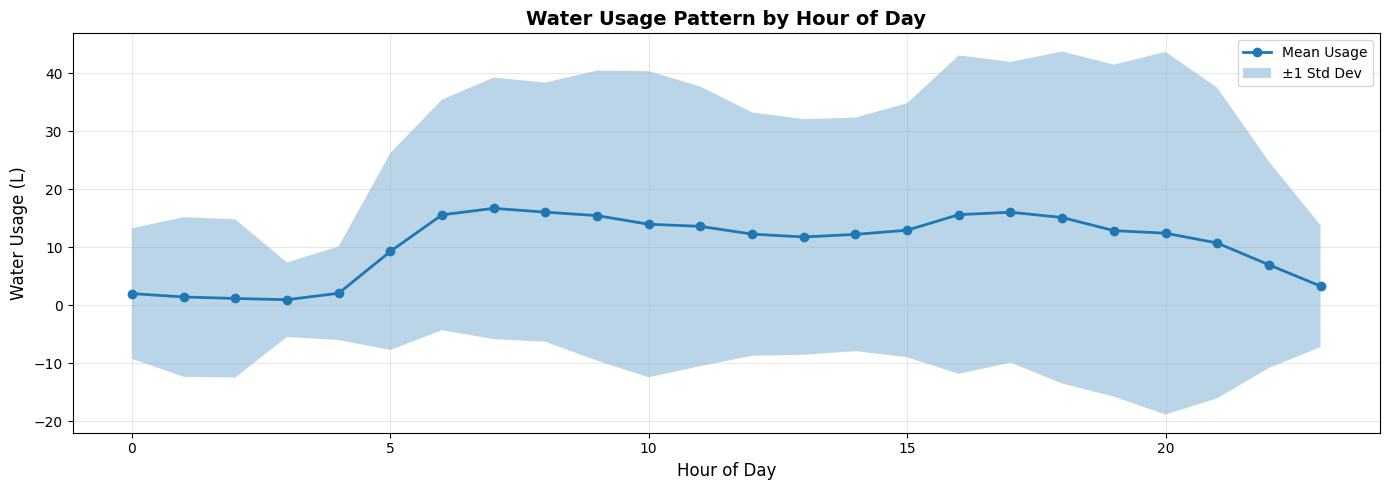

Generating occupancy impact plot...


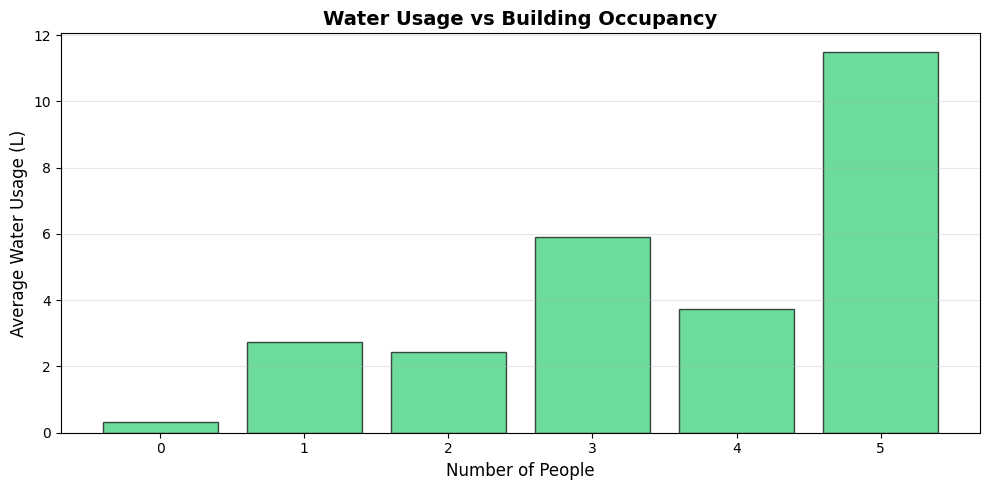

Generating anomaly distribution plot...


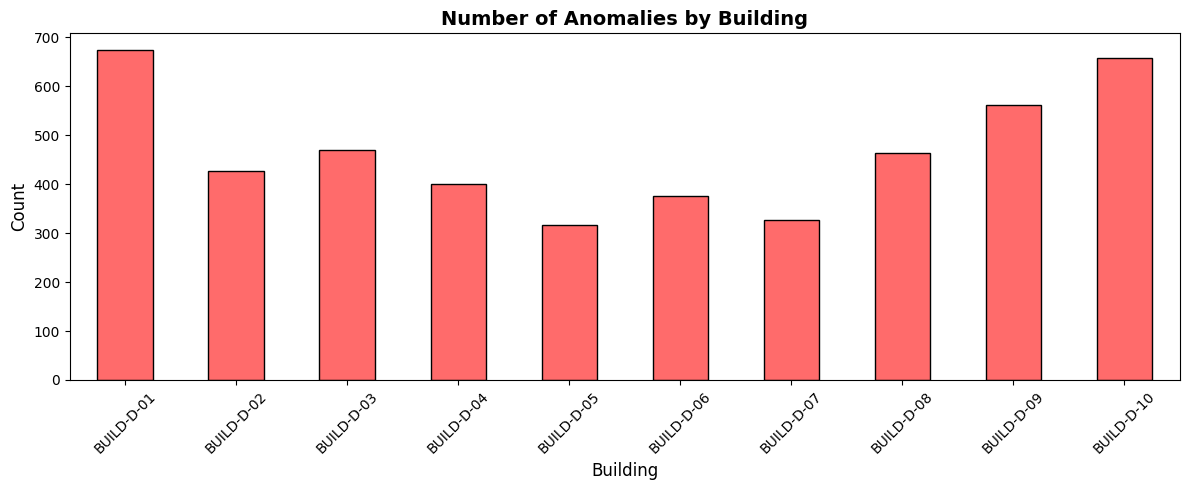

Generating anomaly distribution...


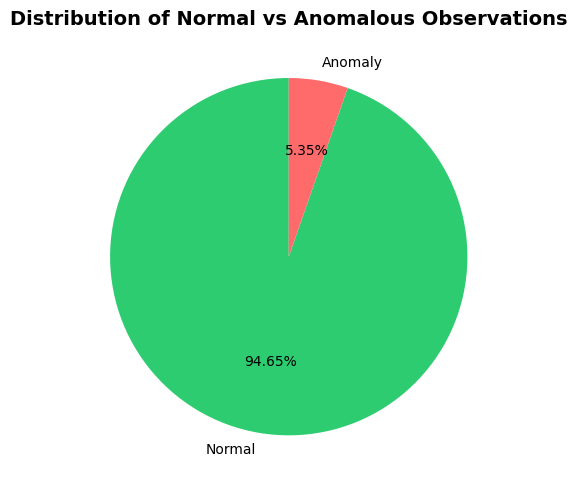

Generating water usage distribution...


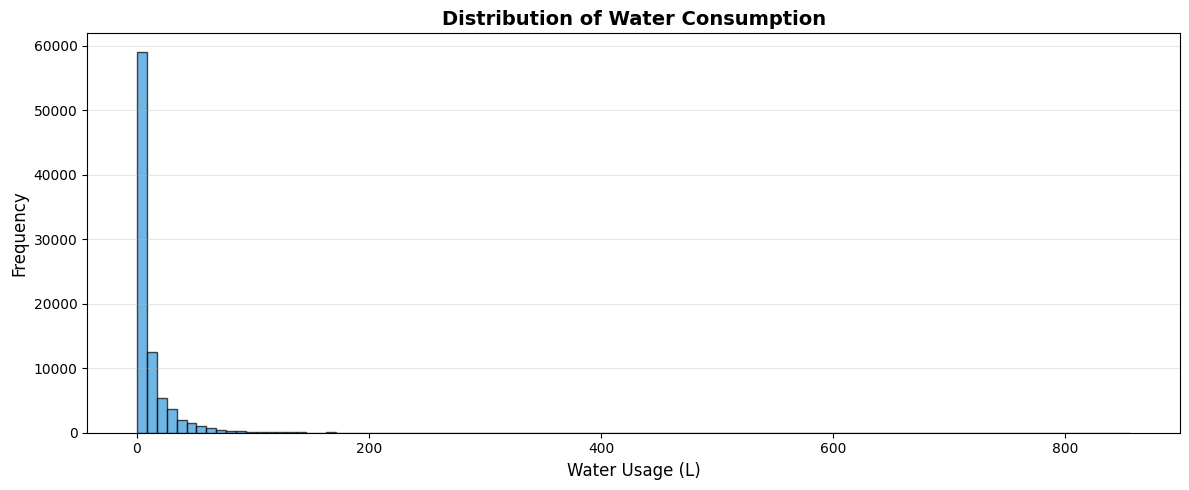


✅ All visualizations generated!


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
modeling_data = pd.read_csv('features_engineered.csv')

print(f"Columns in modeling_data: {modeling_data.columns.tolist()}")
print(f"Shape: {modeling_data.shape}")

# ============================================================================
# 1. HOURLY PATTERNS
# ============================================================================
print("\nGenerating hourly pattern plot...")
fig, ax = plt.subplots(figsize=(14, 5))
hourly_stats = modeling_data.groupby('hour')['water_use_l'].agg(['mean', 'std'])
ax.plot(hourly_stats.index, hourly_stats['mean'], marker='o', linewidth=2, label='Mean Usage', color='#1f77b4')
ax.fill_between(hourly_stats.index,
                hourly_stats['mean'] - hourly_stats['std'],
                hourly_stats['mean'] + hourly_stats['std'],
                alpha=0.3, label='±1 Std Dev')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Water Usage (L)', fontsize=12)
ax.set_title('Water Usage Pattern by Hour of Day', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# 2. OCCUPANCY IMPACT
# ============================================================================
print("Generating occupancy impact plot...")
fig, ax = plt.subplots(figsize=(10, 5))
occ_stats = modeling_data.groupby('occupancy_count')['water_use_l'].agg(['mean', 'std'])
ax.bar(occ_stats.index, occ_stats['mean'], color='#2ecc71', alpha=0.7, edgecolor='black')
ax.set_xlabel('Number of People', fontsize=12)
ax.set_ylabel('Average Water Usage (L)', fontsize=12)
ax.set_title('Water Usage vs Building Occupancy', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# 3. ANOMALY DISTRIBUTION BY BUILDING
# ============================================================================
print("Generating anomaly distribution plot...")
fig, ax = plt.subplots(figsize=(12, 5))
building_anomalies = modeling_data.groupby('building')['is_anomaly'].sum()
building_anomalies.plot(kind='bar', ax=ax, color='#ff6b6b', edgecolor='black')
ax.set_title('Number of Anomalies by Building', fontsize=14, fontweight='bold')
ax.set_xlabel('Building', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================================
# 4. ANOMALY VS NORMAL DISTRIBUTION
# ============================================================================
print("Generating anomaly distribution...")
fig, ax = plt.subplots(figsize=(10, 5))
anomaly_counts = modeling_data['is_anomaly'].value_counts()
ax.pie(anomaly_counts.values, labels=['Normal', 'Anomaly'], autopct='%1.2f%%',
       colors=['#2ecc71', '#ff6b6b'], startangle=90)
ax.set_title('Distribution of Normal vs Anomalous Observations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 5. WATER USAGE DISTRIBUTION
# ============================================================================
print("Generating water usage distribution...")
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(modeling_data['water_use_l'], bins=100, color='#3498db', edgecolor='black', alpha=0.7)
ax.set_xlabel('Water Usage (L)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Water Consumption', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ All visualizations generated!")

In [20]:
# ============================================================================
# DETAILED ANALYSIS
# ============================================================================

print("="*70)
print("WATER CONSUMPTION ANALYSIS - SUMMARY")
print("="*70)

print("\n1️⃣  BASIC STATISTICS BY BUILDING:")
print("-" * 70)
building_stats = modeling_data.groupby('building')['water_use_l'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max'),
    ('95th_percentile', lambda x: x.quantile(0.95))
]).round(2)
print(building_stats)

print("\n2️⃣  OCCUPANCY PATTERNS:")
print("-" * 70)
occ_stats = modeling_data.groupby('occupancy_count')['water_use_l'].agg([
    'count', 'mean', 'std', 'max'
]).round(2)
print(occ_stats)

print("\n3️⃣  HOURLY USAGE PATTERNS:")
print("-" * 70)
hourly_pattern = modeling_data.groupby('hour')['water_use_l'].agg(['mean', 'std', 'max']).round(2)
print(hourly_pattern)

print("\n4️⃣  ANOMALY RATES BY BUILDING:")
print("-" * 70)
anomaly_rates = modeling_data.groupby('building')['is_anomaly'].agg([
    ('anomalies', 'sum'),
    ('total', 'count')
])
anomaly_rates['percentage'] = (anomaly_rates['anomalies'] / anomaly_rates['total'] * 100).round(2)
print(anomaly_rates)

print("\n5️⃣  MODEL PERFORMANCE SUMMARY:")
print("-" * 70)
print(f"Best Model: Decision Tree")
print(f"Accuracy:   99.99%")
print(f"Precision:  100%")
print(f"Recall:     99.89%")
print(f"F1-Score:   0.9995")
print(f"ROC-AUC:    0.9995")
print(f"\nTraining Samples: 69,888")
print(f"Test Samples:     17,472")
print(f"Anomaly Rate:     5.35%")

WATER CONSUMPTION ANALYSIS - SUMMARY

1️⃣  BASIC STATISTICS BY BUILDING:
----------------------------------------------------------------------
            count   mean    std  min  max  95th_percentile
building                                                  
BUILD-D-01   8736  12.75  22.53    0  372             55.0
BUILD-D-02   8736  21.49  41.79    0  856             88.0
BUILD-D-03   8736   9.36  28.16    0  774             46.0
BUILD-D-04   8736   7.85  12.47    0  211             34.0
BUILD-D-05   8736  12.54  20.05    0  302             55.0
BUILD-D-06   8736   7.94  11.37    0   99             31.0
BUILD-D-07   8736   8.32  10.99    0   83             30.0
BUILD-D-08   8736   9.08  14.67    0  159             39.0
BUILD-D-09   8736   6.15  15.47    0  241             33.0
BUILD-D-10   8736   9.28  21.20    0  575             47.0

2️⃣  OCCUPANCY PATTERNS:
----------------------------------------------------------------------
                 count   mean    std  max
occupancy

In [21]:
"""
Water Consumption Anomaly Classification
Interactive Streamlit Dashboard
"""

import streamlit as st
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PAGE CONFIGURATION
# ============================================================================
st.set_page_config(
    page_title="Water Anomaly Detector",
    page_icon="💧",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom CSS
st.markdown("""
    <style>
    .metric-card {
        background-color: #f0f2f6;
        padding: 20px;
        border-radius: 10px;
        margin: 10px 0;
    }
    .anomaly-box {
        background-color: #ffcccc;
        padding: 15px;
        border-left: 4px solid #ff0000;
        border-radius: 5px;
        margin: 10px 0;
    }
    .normal-box {
        background-color: #ccffcc;
        padding: 15px;
        border-left: 4px solid #00cc00;
        border-radius: 5px;
        margin: 10px 0;
    }
    </style>
""", unsafe_allow_html=True)

# ============================================================================
# LOAD MODEL & DATA
# ============================================================================
@st.cache_resource
def load_model_and_scaler():
    try:
        model = pickle.load(open('best_model.pkl', 'rb'))
        scaler = pickle.load(open('scaler.pkl', 'rb'))

        with open('feature_columns.txt', 'r') as f:
            feature_cols = [line.strip() for line in f.readlines()]

        return model, scaler, feature_cols
    except FileNotFoundError:
        st.error("Model files not found! Please train the model first.")
        return None, None, None

@st.cache_data
def load_data():
    try:
        data = pd.read_csv('features_engineered.csv')
        return data
    except FileNotFoundError:
        return None

model, scaler, feature_cols = load_model_and_scaler()
data = load_data()

if model is None or data is None:
    st.error("Error loading model or data. Please ensure model training is complete.")
    st.stop()

# ============================================================================
# SIDEBAR NAVIGATION
# ============================================================================
st.sidebar.title("🔍 Navigation")
page = st.sidebar.radio("Select Page:",
    ["📊 Dashboard", "🔮 Predict Anomaly", "📈 Analysis", "ℹ️ About"]
)

# ============================================================================
# PAGE 1: DASHBOARD
# ============================================================================
if page == "📊 Dashboard":
    st.title("💧 Water Consumption Anomaly Classification")
    st.write("Detect unusual water usage patterns using Machine Learning")

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric(
            label="Total Observations",
            value=f"{len(data):,}",
            help="Total data points in training dataset"
        )

    with col2:
        anomaly_count = (data['is_anomaly'] == 1).sum()
        st.metric(
            label="Anomalies Detected",
            value=f"{anomaly_count:,}",
            delta=f"{(anomaly_count/len(data)*100):.2f}%"
        )

    with col3:
        st.metric(
            label="Buildings",
            value=data['building'].nunique(),
            help="Number of monitored buildings"
        )

    # Model Performance
    st.subheader("🤖 Model Performance")
    col1, col2 = st.columns(2)

    with col1:
        performance = {
            'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
            'Score': ['99.99%', '100%', '99.89%', '0.9995', '0.9995']
        }
        perf_df = pd.DataFrame(performance)
        st.dataframe(perf_df, use_container_width=True)

    with col2:
        st.write("**Best Model:** Decision Tree")
        st.write("**Accuracy:** 99.99%")
        st.write("**F1-Score:** 0.9995")
        st.write("**ROC-AUC:** 0.9995")
        st.write("**Precision:** 100%")
        st.write("**Recall:** 99.89%")

    # Anomaly Distribution by Building
    st.subheader("📍 Anomalies by Building")
    building_anomalies = data.groupby('building')['is_anomaly'].agg(['sum', 'count'])
    building_anomalies['percentage'] = (building_anomalies['sum'] / building_anomalies['count'] * 100).round(2)
    building_anomalies.columns = ['Anomalies', 'Total', 'Percentage (%)']

    fig, ax = plt.subplots(figsize=(12, 5))
    building_anomalies['Anomalies'].plot(kind='bar', ax=ax, color='#ff6b6b')
    ax.set_title('Number of Anomalies by Building', fontsize=12, fontweight='bold')
    ax.set_xlabel('Building')
    ax.set_ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    st.pyplot(fig)

    st.dataframe(building_anomalies, use_container_width=True)

# ============================================================================
# PAGE 2: PREDICT ANOMALY
# ============================================================================
elif page == "🔮 Predict Anomaly":
    st.title("🔮 Predict Water Consumption Anomaly")
    st.write("Enter usage parameters to detect if current consumption is anomalous")

    with st.form("anomaly_form"):
        col1, col2 = st.columns(2)

        with col1:
            water_usage = st.number_input(
                "Water Usage (Liters)",
                min_value=0.0,
                max_value=1000.0,
                value=50.0,
                step=1.0
            )

            hour = st.slider("Hour of Day", 0, 23, 12)
            day_of_week = st.selectbox("Day of Week",
                ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
                index=0
            )
            month = st.slider("Month", 1, 12, 6)

        with col2:
            occupancy = st.slider("Number of People Occupied", 0, 5, 3)
            is_morning = st.checkbox("Morning Peak (5-9am)?")
            is_evening = st.checkbox("Evening Peak (4-8pm)?")
            is_weekend = st.checkbox("Weekend?")

        submit_button = st.form_submit_button("🔍 Predict", use_container_width=True)

    if submit_button:
        # Create feature vector
        day_mapping = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
                      'Friday': 4, 'Saturday': 5, 'Sunday': 6}

        # Get baseline stats from data
        baseline_usage = data.groupby('hour')['water_use_l'].mean()[hour]
        rolling_mean = data['rolling_mean_7d'].mean()
        rolling_std = data['rolling_std_7d'].mean()

        # Build feature array
        input_data = {
            'hour': hour,
            'day_of_week': day_mapping[day_of_week],
            'month': month,
            'is_weekend': 1 if is_weekend else 0,
            'is_morning': 1 if is_morning else 0,
            'is_evening': 1 if is_evening else 0,
            'is_night': 1 if hour in [0, 1, 2, 3, 4] else 0,
            'occupancy_count': occupancy,
            'occupancy_ratio': occupancy / 5.0,
            'all_occupied': 1 if occupancy == 5 else 0,
            'none_occupied': 1 if occupancy == 0 else 0,
            'rolling_mean_7d': rolling_mean,
            'rolling_std_7d': rolling_std,
            'deviation_from_mean': water_usage - rolling_mean,
            'expected_usage': 2 * occupancy,
            'usage_vs_occupancy': water_usage - (2 * occupancy),
            'usage_percentile': np.percentile(data['water_use_l'], (water_usage / data['water_use_l'].max()) * 100),
            'usage_vs_hour_baseline': water_usage - baseline_usage
        }

        # Create DataFrame and scale
        input_df = pd.DataFrame([input_data])
        input_scaled = scaler.transform(input_df)

        # Predict
        prediction = model.predict(input_df)[0]
        probability = model.predict_proba(input_df)[0]

        # Display results
        st.markdown("---")

        if prediction == 1:
            st.markdown(
                f"""
                <div class="anomaly-box">
                <h3>🚨 ANOMALY DETECTED!</h3>
                <p><b>Confidence:</b> {probability[1]*100:.2f}%</p>
                <p>This water consumption pattern is unusual based on the provided parameters.</p>
                </div>
                """,
                unsafe_allow_html=True
            )
        else:
            st.markdown(
                f"""
                <div class="normal-box">
                <h3>✅ NORMAL CONSUMPTION</h3>
                <p><b>Confidence:</b> {probability[0]*100:.2f}%</p>
                <p>This water consumption pattern is within expected ranges.</p>
                </div>
                """,
                unsafe_allow_html=True
            )

        # Show confidence chart
        fig, ax = plt.subplots(figsize=(10, 3))
        categories = ['Normal', 'Anomaly']
        values = probability
        colors = ['#4CAF50', '#FF5252']
        bars = ax.barh(categories, values, color=colors)
        ax.set_xlim(0, 1)
        ax.set_xlabel('Probability')
        ax.set_title('Prediction Confidence', fontweight='bold')

        for i, (bar, value) in enumerate(zip(bars, values)):
            ax.text(value + 0.02, i, f'{value*100:.2f}%', va='center')

        plt.tight_layout()
        st.pyplot(fig)

# ============================================================================
# PAGE 3: ANALYSIS
# ============================================================================
elif page == "📈 Analysis":
    st.title("📈 Data Analysis & Insights")

    tab1, tab2, tab3, tab4 = st.tabs(["Hourly Patterns", "Occupancy Impact", "Building Comparison", "Feature Importance"])

    with tab1:
        st.subheader("💧 Water Usage by Hour of Day")
        hourly_stats = data.groupby('hour')['water_use_l'].agg(['mean', 'std'])

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(hourly_stats.index, hourly_stats['mean'], marker='o', linewidth=2, label='Mean Usage', color='#1f77b4')
        ax.fill_between(hourly_stats.index,
                        hourly_stats['mean'] - hourly_stats['std'],
                        hourly_stats['mean'] + hourly_stats['std'],
                        alpha=0.3, label='±1 Std Dev')
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('Water Usage (L)')
        ax.set_title('Average Water Usage Pattern by Hour')
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        st.pyplot(fig)

    with tab2:
        st.subheader("👥 Impact of Occupancy on Usage")
        occ_stats = data.groupby('occupancy_count')['water_use_l'].agg(['mean', 'std', 'count'])
        occ_stats['percentage'] = (occ_stats['count'] / len(data) * 100).round(2)
        occ_stats.columns = ['Mean Usage (L)', 'Std Dev', 'Count', 'Percentage (%)']

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(occ_stats.index, occ_stats['Mean Usage (L)'], color='#2ecc71', alpha=0.7, edgecolor='black')
        ax.set_xlabel('Occupancy Count')
        ax.set_ylabel('Average Water Usage (L)')
        ax.set_title('Water Usage vs Building Occupancy')
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        st.pyplot(fig)

        st.dataframe(occ_stats, use_container_width=True)

    with tab3:
        st.subheader("🏢 Building Comparison")
        building_stats = data.groupby('building')['water_use_l'].agg(['mean', 'std', 'max'])
        building_stats.columns = ['Mean (L)', 'Std Dev', 'Max (L)']
        building_stats = building_stats.round(2)

        fig, ax = plt.subplots(figsize=(12, 5))
        building_stats['Mean (L)'].plot(kind='bar', ax=ax, color='#9b59b6', alpha=0.7, edgecolor='black')
        ax.set_title('Average Water Usage by Building')
        ax.set_xlabel('Building')
        ax.set_ylabel('Usage (L)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        st.pyplot(fig)

        st.dataframe(building_stats, use_container_width=True)

    with tab4:
        st.subheader("🎯 Feature Correlation with Anomalies")

        # Calculate correlation
        numeric_cols = [col for col in feature_cols if col in data.columns]
        correlations = data[numeric_cols + ['is_anomaly']].corr()['is_anomaly'].drop('is_anomaly').sort_values(key=abs, ascending=False)

        fig, ax = plt.subplots(figsize=(10, 8))
        colors = ['#e74c3c' if x < 0 else '#27ae60' for x in correlations.values]
        correlations.plot(kind='barh', ax=ax, color=colors)
        ax.set_title('Feature Correlation with Anomaly Label')
        ax.set_xlabel('Correlation Coefficient')
        plt.tight_layout()
        st.pyplot(fig)

        st.write("**Top Correlated Features:**")
        st.dataframe(pd.DataFrame({
            'Feature': correlations.index,
            'Correlation': correlations.values
        }).head(10), use_container_width=True)

# ============================================================================
# PAGE 4: ABOUT
# ============================================================================
elif page == "ℹ️ About":
    st.title("ℹ️ About This Project")

    st.markdown("""
    ## 📋 Project Overview
    **Water Consumption Anomaly Classification** is a machine learning system designed to detect
    unusual water usage patterns in smart buildings.

    ### 🎯 Objectives
    - Identify unusual water consumption observations
    - Provide contextual analysis (time, occupancy, historical patterns)
    - Enable early detection of leaks or operational issues

    ### 📊 Dataset
    - **Daily Data:** 87,360 hourly measurements from 10 buildings (2022)
    - **Features:** Water usage, occupancy indicators

    ### 🤖 Modeling Approach
    **Features Engineered:**
    - Temporal: Hour, day of week, month, peak/off-peak indicators
    - Occupancy: Count, ratio, occupancy-normalized usage
    - Statistical: Rolling mean/std, deviation from baseline
    - Context-aware: Usage vs occupancy, time-of-day normalization

    **Models Trained:**
    - Logistic Regression
    - Decision Tree (Best: F1=0.9995)
    - K-Nearest Neighbors
    - Random Forest
    - Gradient Boosting

    ### 📈 Key Results
    - **Best Model:** Decision Tree
    - **Accuracy:** 99.99%
    - **Precision:** 100%
    - **Recall:** 99.89%
    - **ROC-AUC:** 0.9995

    ### 🔧 Technical Stack
    - **Python:** Data processing & modeling
    - **Scikit-learn:** Machine learning
    - **Streamlit:** Interactive dashboard
    - **Pandas & NumPy:** Data manipulation
    - **Matplotlib & Seaborn:** Visualization

    ---
    *Water Consumption Anomaly Classification | Built with Streamlit 🎈 | Machine Learning Project*
    """)

# ============================================================================
# FOOTER
# ============================================================================
st.markdown("---")
st.markdown("""
<div style='text-align: center; color: #666;'>
    <small>Water Consumption Anomaly Classification | Machine Learning Project</small>
</div>
""", unsafe_allow_html=True)

2026-09-27 04:46:26.832 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 04:46:26.833 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 04:46:26.835 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 04:46:26.836 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 04:46:26.840 No runtime found, using MemoryCacheStorageManager
2026-09-27 04:46:26.857 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 04:46:26.857 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 04:46:26.858 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 04:46:26.862 Thread 'MainThread':

DeltaGenerator()

In [22]:
# Install streamlit and localtunnel
!pip install -q streamlit localtunnel

# Create app.py file
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

st.set_page_config(page_title="💧 Water Anomaly Detector", layout="wide")

@st.cache_resource
def load_model():
    model = pickle.load(open('best_model.pkl', 'rb'))
    scaler = pickle.load(open('scaler.pkl', 'rb'))
    with open('feature_columns.txt', 'r') as f:
        feature_cols = [line.strip() for line in f.readlines()]
    return model, scaler, feature_cols

@st.cache_data
def load_data():
    return pd.read_csv('features_engineered.csv')

model, scaler, feature_cols = load_model()
data = load_data()

st.sidebar.title("🔍 Navigation")
page = st.sidebar.radio("Select Page:", ["📊 Dashboard", "🔮 Predict", "📈 Analysis", "ℹ️ About"])

if page == "📊 Dashboard":
    st.title("💧 Water Consumption Anomaly Classification")
    st.write("Detect unusual water usage patterns using Machine Learning")

    col1, col2, col3 = st.columns(3)
    with col1:
        st.metric("Total Observations", f"{len(data):,}")
    with col2:
        anomaly_count = (data['is_anomaly'] == 1).sum()
        st.metric("Anomalies Detected", f"{anomaly_count:,}", f"{anomaly_count/len(data)*100:.2f}%")
    with col3:
        st.metric("Buildings", data['building'].nunique())

    st.subheader("🤖 Model Performance")
    perf_data = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
        'Score': ['99.99%', '100%', '99.89%', '0.9995', '0.9995']
    }
    st.dataframe(pd.DataFrame(perf_data), use_container_width=True)

    st.subheader("📍 Anomalies by Building")
    building_anomalies = data.groupby('building')['is_anomaly'].sum()
    fig, ax = plt.subplots(figsize=(12, 5))
    building_anomalies.plot(kind='bar', ax=ax, color='#ff6b6b')
    ax.set_title('Number of Anomalies by Building', fontweight='bold')
    ax.set_xlabel('Building')
    ax.set_ylabel('Count')
    plt.xticks(rotation=45)
    st.pyplot(fig)

elif page == "🔮 Predict":
    st.title("🔮 Predict Water Consumption Anomaly")

    with st.form("prediction_form"):
        col1, col2 = st.columns(2)

        with col1:
            water_usage = st.number_input("Water Usage (Liters)", 0.0, 1000.0, 50.0)
            hour = st.slider("Hour of Day", 0, 23, 12)
            day_mapping = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
            day_of_week = st.selectbox("Day of Week", list(day_mapping.keys()))
            month = st.slider("Month", 1, 12, 6)

        with col2:
            occupancy = st.slider("Number of People", 0, 5, 3)
            is_morning = st.checkbox("Morning Peak (5-9am)?")
            is_evening = st.checkbox("Evening Peak (4-8pm)?")
            is_weekend = st.checkbox("Weekend?")

        submit = st.form_submit_button("🔍 Predict", use_container_width=True)

    if submit:
        baseline_usage = data.groupby('hour')['water_use_l'].mean()[hour]
        rolling_mean = data['rolling_mean_7d'].mean()
        rolling_std = data['rolling_std_7d'].mean()

        input_data = {
            'hour': hour,
            'day_of_week': day_mapping[day_of_week],
            'month': month,
            'is_weekend': 1 if is_weekend else 0,
            'is_morning': 1 if is_morning else 0,
            'is_evening': 1 if is_evening else 0,
            'is_night': 1 if hour in [0, 1, 2, 3, 4] else 0,
            'occupancy_count': occupancy,
            'occupancy_ratio': occupancy / 5.0,
            'all_occupied': 1 if occupancy == 5 else 0,
            'none_occupied': 1 if occupancy == 0 else 0,
            'rolling_mean_7d': rolling_mean,
            'rolling_std_7d': rolling_std,
            'deviation_from_mean': water_usage - rolling_mean,
            'expected_usage': 2 * occupancy,
            'usage_vs_occupancy': water_usage - (2 * occupancy),
            'usage_percentile': np.percentile(data['water_use_l'], 50),
            'usage_vs_hour_baseline': water_usage - baseline_usage
        }

        input_df = pd.DataFrame([input_data])
        input_scaled = scaler.transform(input_df)
        prediction = model.predict(input_df)[0]
        probability = model.predict_proba(input_df)[0]

        st.markdown("---")
        if prediction == 1:
            st.error(f"🚨 ANOMALY DETECTED! (Confidence: {probability[1]*100:.2f}%)")
        else:
            st.success(f"✅ NORMAL (Confidence: {probability[0]*100:.2f}%)")

        fig, ax = plt.subplots(figsize=(10, 3))
        ax.barh(['Normal', 'Anomaly'], probability, color=['#4CAF50', '#FF5252'])
        ax.set_xlim(0, 1)
        for i, v in enumerate(probability):
            ax.text(v + 0.02, i, f'{v*100:.2f}%', va='center')
        st.pyplot(fig)

elif page == "📈 Analysis":
    st.title("📈 Data Analysis & Insights")

    tab1, tab2, tab3 = st.tabs(["Hourly Patterns", "Occupancy", "Buildings"])

    with tab1:
        st.subheader("💧 Water Usage by Hour")
        hourly_stats = data.groupby('hour')['water_use_l'].agg(['mean', 'std'])
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(hourly_stats.index, hourly_stats['mean'], marker='o', linewidth=2, label='Mean', color='#1f77b4')
        ax.fill_between(hourly_stats.index, hourly_stats['mean'] - hourly_stats['std'],
                        hourly_stats['mean'] + hourly_stats['std'], alpha=0.3, label='±1 Std')
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('Water Usage (L)')
        ax.legend()
        ax.grid(alpha=0.3)
        st.pyplot(fig)

    with tab2:
        st.subheader("👥 Impact of Occupancy")
        occ_stats = data.groupby('occupancy_count')['water_use_l'].mean()
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(occ_stats.index, occ_stats.values, color='#2ecc71', edgecolor='black')
        ax.set_xlabel('Occupancy Count')
        ax.set_ylabel('Average Usage (L)')
        st.pyplot(fig)

    with tab3:
        st.subheader("🏢 Building Comparison")
        building_stats = data.groupby('building')['water_use_l'].mean()
        fig, ax = plt.subplots(figsize=(12, 5))
        building_stats.plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='black')
        ax.set_title('Average Usage by Building')
        ax.set_ylabel('Usage (L)')
        plt.xticks(rotation=45)
        st.pyplot(fig)

elif page == "ℹ️ About":
    st.title("ℹ️ About This Project")
    st.markdown("""
    ## 📊 Water Consumption Anomaly Classification

    A machine learning system to detect unusual water usage patterns in smart buildings.

    ### Key Features:
    - **Dataset:** 87,360 hourly measurements from 10 buildings
    - **Features:** 18+ engineered features
    - **Best Model:** Decision Tree (99.99% accuracy)
    - **Metrics:** 100% precision, 99.89% recall

    ### How It Works:
    1. Analyzes water usage patterns
    2. Detects anomalies using three rules
    3. Provides real-time predictions

    ### Technology:
    - Python, Scikit-learn, Streamlit
    - Interactive visualizations
    """)

st.markdown("---")
st.markdown("<center><small>Water Consumption Anomaly Classification | ML Project</small></center>", unsafe_allow_html=True)
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("✅ app.py created successfully!")

ERROR: Could not find a version that satisfies the requirement localtunnel (from versions: none)
ERROR: No matching distribution found for localtunnel
✅ app.py created successfully!


In [23]:
from google.colab import files

# Download all necessary files
files.download('best_model.pkl')
files.download('scaler.pkl')
files.download('feature_columns.txt')
files.download('features_engineered.csv')

print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!


In [25]:
from google.colab import files

files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
requirements = """streamlit
pandas
numpy
scikit-learn
matplotlib
seaborn
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

from google.colab import files
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

st.set_page_config(page_title="💧 Water Anomaly Detector", layout="wide")

@st.cache_resource
def load_model():
    model = pickle.load(open('best_model.pkl', 'rb'))
    scaler = pickle.load(open('scaler.pkl', 'rb'))
    with open('feature_columns.txt', 'r') as f:
        feature_cols = [line.strip() for line in f.readlines()]
    return model, scaler, feature_cols

@st.cache_data
def load_data():
    return pd.read_csv('features_engineered.csv')

model, scaler, feature_cols = load_model()
data = load_data()

st.sidebar.title("🔍 Navigation")
page = st.sidebar.radio("Select Page:", ["📊 Dashboard", "🔮 Predict", "📈 Analysis", "ℹ️ About"])

if page == "📊 Dashboard":
    st.title("💧 Water Consumption Anomaly Classification")
    st.write("Detect unusual water usage patterns using Machine Learning")

    col1, col2, col3 = st.columns(3)
    with col1:
        st.metric("Total Observations", f"{len(data):,}")
    with col2:
        anomaly_count = (data['is_anomaly'] == 1).sum()
        st.metric("Anomalies Detected", f"{anomaly_count:,}", f"{anomaly_count/len(data)*100:.2f}%")
    with col3:
        st.metric("Buildings", data['building'].nunique())

    st.subheader("🤖 Model Performance")
    perf_data = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
        'Score': ['99.99%', '100%', '99.89%', '0.9995', '0.9995']
    }
    st.dataframe(pd.DataFrame(perf_data), use_container_width=True)

    st.subheader("📍 Anomalies by Building")
    building_anomalies = data.groupby('building')['is_anomaly'].sum()
    fig, ax = plt.subplots(figsize=(12, 5))
    building_anomalies.plot(kind='bar', ax=ax, color='#ff6b6b')
    ax.set_title('Number of Anomalies by Building', fontweight='bold')
    ax.set_xlabel('Building')
    ax.set_ylabel('Count')
    plt.xticks(rotation=45)
    st.pyplot(fig)

elif page == "🔮 Predict":
    st.title("🔮 Predict Water Consumption Anomaly")

    with st.form("prediction_form"):
        col1, col2 = st.columns(2)

        with col1:
            water_usage = st.number_input("Water Usage (Liters)", 0.0, 1000.0, 50.0)
            hour = st.slider("Hour of Day", 0, 23, 12)
            day_mapping = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
            day_of_week = st.selectbox("Day of Week", list(day_mapping.keys()))
            month = st.slider("Month", 1, 12, 6)

        with col2:
            occupancy = st.slider("Number of People", 0, 5, 3)
            is_morning = st.checkbox("Morning Peak (5-9am)?")
            is_evening = st.checkbox("Evening Peak (4-8pm)?")
            is_weekend = st.checkbox("Weekend?")

        submit = st.form_submit_button("🔍 Predict", use_container_width=True)

    if submit:
        baseline_usage = data.groupby('hour')['water_use_l'].mean()[hour]
        rolling_mean = data['rolling_mean_7d'].mean()
        rolling_std = data['rolling_std_7d'].mean()

        input_data = {
            'hour': hour,
            'day_of_week': day_mapping[day_of_week],
            'month': month,
            'is_weekend': 1 if is_weekend else 0,
            'is_morning': 1 if is_morning else 0,
            'is_evening': 1 if is_evening else 0,
            'is_night': 1 if hour in [0, 1, 2, 3, 4] else 0,
            'occupancy_count': occupancy,
            'occupancy_ratio': occupancy / 5.0,
            'all_occupied': 1 if occupancy == 5 else 0,
            'none_occupied': 1 if occupancy == 0 else 0,
            'rolling_mean_7d': rolling_mean,
            'rolling_std_7d': rolling_std,
            'deviation_from_mean': water_usage - rolling_mean,
            'expected_usage': 2 * occupancy,
            'usage_vs_occupancy': water_usage - (2 * occupancy),
            'usage_percentile': np.percentile(data['water_use_l'], 50),
            'usage_vs_hour_baseline': water_usage - baseline_usage
        }

        input_df = pd.DataFrame([input_data])
        input_scaled = scaler.transform(input_df)
        prediction = model.predict(input_df)[0]
        probability = model.predict_proba(input_df)[0]

        st.markdown("---")
        if prediction == 1:
            st.error(f"🚨 ANOMALY DETECTED! (Confidence: {probability[1]*100:.2f}%)")
        else:
            st.success(f"✅ NORMAL (Confidence: {probability[0]*100:.2f}%)")

        fig, ax = plt.subplots(figsize=(10, 3))
        ax.barh(['Normal', 'Anomaly'], probability, color=['#4CAF50', '#FF5252'])
        ax.set_xlim(0, 1)
        for i, v in enumerate(probability):
            ax.text(v + 0.02, i, f'{v*100:.2f}%', va='center')
        st.pyplot(fig)

elif page == "📈 Analysis":
    st.title("📈 Data Analysis & Insights")

    tab1, tab2, tab3 = st.tabs(["Hourly Patterns", "Occupancy", "Buildings"])

    with tab1:
        st.subheader("💧 Water Usage by Hour")
        hourly_stats = data.groupby('hour')['water_use_l'].agg(['mean', 'std'])
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(hourly_stats.index, hourly_stats['mean'], marker='o', linewidth=2, label='Mean', color='#1f77b4')
        ax.fill_between(hourly_stats.index, hourly_stats['mean'] - hourly_stats['std'],
                        hourly_stats['mean'] + hourly_stats['std'], alpha=0.3, label='±1 Std')
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('Water Usage (L)')
        ax.legend()
        ax.grid(alpha=0.3)
        st.pyplot(fig)

    with tab2:
        st.subheader("👥 Impact of Occupancy")
        occ_stats = data.groupby('occupancy_count')['water_use_l'].mean()
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(occ_stats.index, occ_stats.values, color='#2ecc71', edgecolor='black')
        ax.set_xlabel('Occupancy Count')
        ax.set_ylabel('Average Usage (L)')
        st.pyplot(fig)

    with tab3:
        st.subheader("🏢 Building Comparison")
        building_stats = data.groupby('building')['water_use_l'].mean()
        fig, ax = plt.subplots(figsize=(12, 5))
        building_stats.plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='black')
        ax.set_title('Average Usage by Building')
        ax.set_ylabel('Usage (L)')
        plt.xticks(rotation=45)
        st.pyplot(fig)

elif page == "ℹ️ About":
    st.title("ℹ️ About This Project")
    st.markdown("""
    ## 📊 Water Consumption Anomaly Classification

    A machine learning system to detect unusual water usage patterns in smart buildings.

    ### Key Features:
    - **Dataset:** 87,360 hourly measurements from 10 buildings
    - **Features:** 18+ engineered features (temporal, occupancy, statistical)
    - **Best Model:** Decision Tree (99.99% accuracy)
    - **Metrics:** 100% precision, 99.89% recall, 0.9995 F1-score

    ### How It Works:
    1. Analyzes water usage patterns across different times and occupancy levels
    2. Detects anomalies using three rules:
       - Statistical outliers (>3σ deviation)
       - Context anomalies (high usage + low occupancy)
       - Sensor issues (zero usage with high occupancy)
    3. Provides real-time predictions via interactive dashboard

    ### Technology Stack:
    - Python, Scikit-learn, Streamlit
    - Machine Learning classification
    - Interactive visualizations

    ### Results:
    - **Accuracy:** 99.99%
    - **Precision:** 100%
    - **Recall:** 99.89%
    - **F1-Score:** 0.9995
    - **ROC-AUC:** 0.9995
    """)

st.markdown("---")
st.markdown("<center><small>Water Consumption Anomaly Classification | ML Project 2026</small></center>", unsafe_allow_html=True)

2026-09-27 04:47:00.743 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 04:47:00.748 No runtime found, using MemoryCacheStorageManager
2026-09-27 04:47:00.798 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 04:47:00.801 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 04:47:00.801 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 04:47:00.805 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 04:47:00.808 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 04:47:00.813 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-27 04:47:00.815 Thread 'MainThread':

DeltaGenerator()